In [1]:
import torch
import matplotlib.pyplot as plt
import normflows as nf

In [39]:
def make_grid(radius, res_sparse=9, res_dense=32):
    lines = torch.stack(torch.meshgrid(
        torch.linspace(-radius, radius, res_sparse), torch.linspace(-radius, radius, res_dense), indexing='xy'
    ), dim=-1)

    return torch.cat((lines, lines.flip(-1)), dim=1)

In [40]:
grid = make_grid(2)

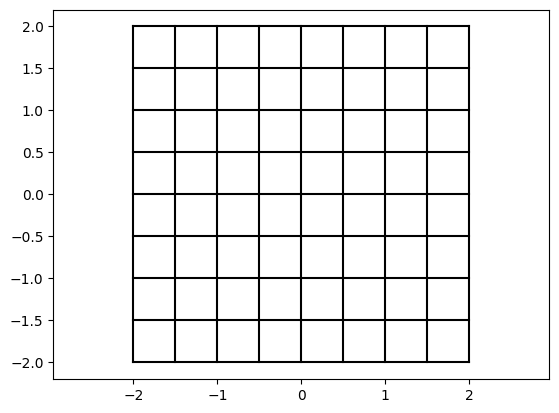

In [41]:
plt.plot(*grid.movedim(-1, 0), c='k')
plt.axis('equal')
plt.show()

In [52]:
num_layers = 16
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=False)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

# Construct flow model
model = nf.NormalizingFlow(None, flows)

In [53]:
with torch.no_grad():
    transformed_grid = model(grid.flatten(end_dim=1)).reshape_as(grid)

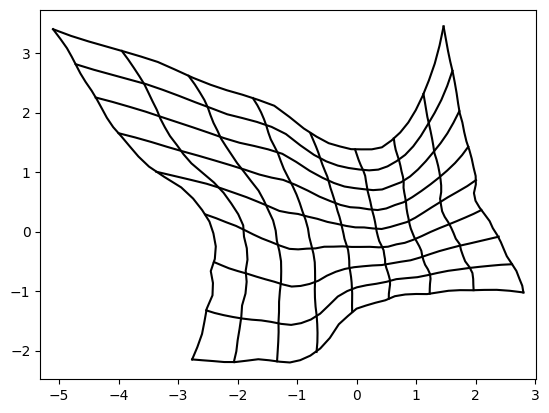

In [54]:
plt.plot(*transformed_grid.movedim(-1, 0), c='k')
plt.axis('equal')
plt.show()